# Real-World Data Project: Stock Price Prediction (Finance)

**Objective:** Predict the next day's closing stock price using 
historical price and volume data.

**Dataset:** stock_prices.csv (500 trading days, OHLCV data)

## Step 1: Import Libraries and Load Data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('stock_prices.csv')
df.head()

,date,open,high,low,close,volume
0,2024-01-01,1553.24,1555.23,1545.69,1546.39,430109
1,2024-01-02,1541.04,1553.34,1536.34,1548.08,561127
2,2024-01-03,1535.54,1549.24,1519.57,1526.87,500309
3,2024-01-04,1528.27,1528.97,1522.83,1527.61,236791
4,2024-01-05,1562.21,1570.19,1553.50,1556.36,590074


## Step 2: Explore the Data

Checking shape, data types, and basic statistics of the price and 
volume columns.

In [11]:
print(df.shape)
print(df.info())
print(df.describe(include="all"))


(500, 6)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    500 non-null    str    
 1   open    500 non-null    float64
 2   high    500 non-null    float64
 3   low     500 non-null    float64
 4   close   500 non-null    float64
 5   volume  500 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 23.6 KB
None
              date         open        high          low        close  \
count          500   500.000000   500.00000   500.000000   500.000000   
unique         500          NaN         NaN          NaN          NaN   
top     2024-01-01          NaN         NaN          NaN          NaN   
freq             1          NaN         NaN          NaN          NaN   
mean           NaN  1599.977420  1610.88054  1588.792600  1599.936560   
std            NaN   158.198102   159.76291   157.336112   158.222374   
min            NaN  1324.44

## Step 3: Visualize the Closing Price Trend

Plotting the closing price over time to see the overall trend before 
building any model.

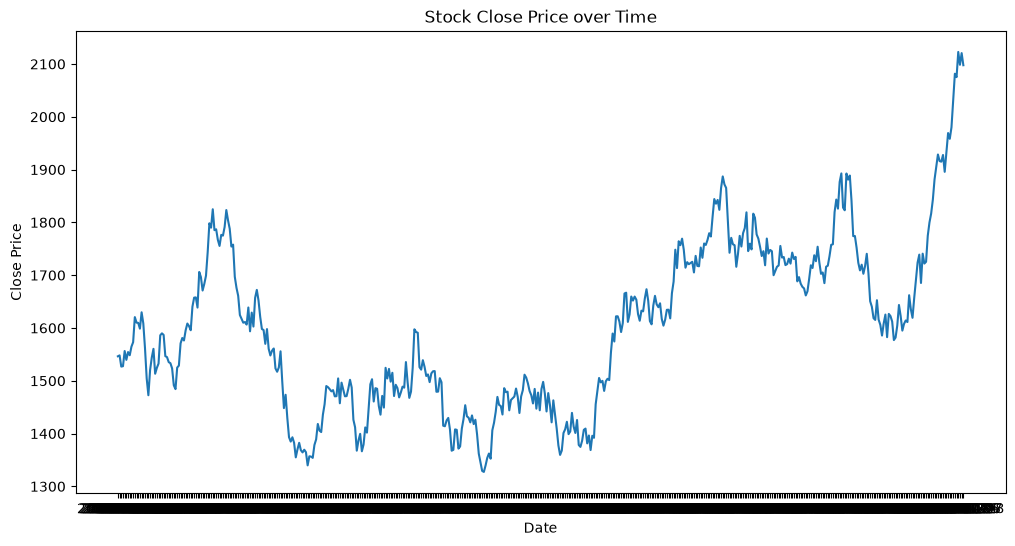

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df['date'],df['close'])
plt.title("Stock Close Price over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

## Step 4: Feature Engineering

Creating useful features for prediction:
- **Moving averages** (7-day, 30-day) — smooth out short-term noise
- **Daily return** — percentage change from previous day
- **Target** — next day's closing price (what we want to predict)

In [13]:
df["ma_7"] = df['close'].rolling(window=7).mean()
df["ma_30"] = df['close'].rolling(window=30).mean()
df["daily_return"] = df['close'].pct_change()
df["target"]=df['close'].shift(-1)
df=df.dropna().reset_index(drop=True)
df.head

<bound method NDFrame.head of            date     open     high      low    close  volume         ma_7  \
0    2024-02-09  1551.64  1556.47  1542.56  1544.80  678962  1558.778571   
1    2024-02-12  1548.79  1557.25  1533.05  1535.31  214044  1560.324286   
2    2024-02-13  1546.32  1547.97  1532.75  1533.33  754930  1560.422857   
3    2024-02-14  1525.34  1526.56  1514.94  1523.51  366521  1551.472857   
4    2024-02-15  1489.79  1497.19  1483.32  1491.54  342497  1537.428571   
..          ...      ...      ...      ...      ...     ...          ...   
465  2025-11-21  2081.57  2083.98  2076.70  2081.57  258085  1978.471429   
466  2025-11-24  2064.91  2092.48  2064.40  2075.09  435103  2004.091429   
467  2025-11-25  2130.15  2155.47  2120.96  2122.80  753257  2031.187143   
468  2025-11-26  2104.84  2109.32  2077.92  2098.50  505799  2049.650000   
469  2025-11-27  2142.60  2145.91  2109.25  2120.59  426731  2072.840000   

           ma_30  daily_return   target  
0    1558.37400

## Step 5: Correlation Check

Checking which features are most related to the target (next day's 
closing price).

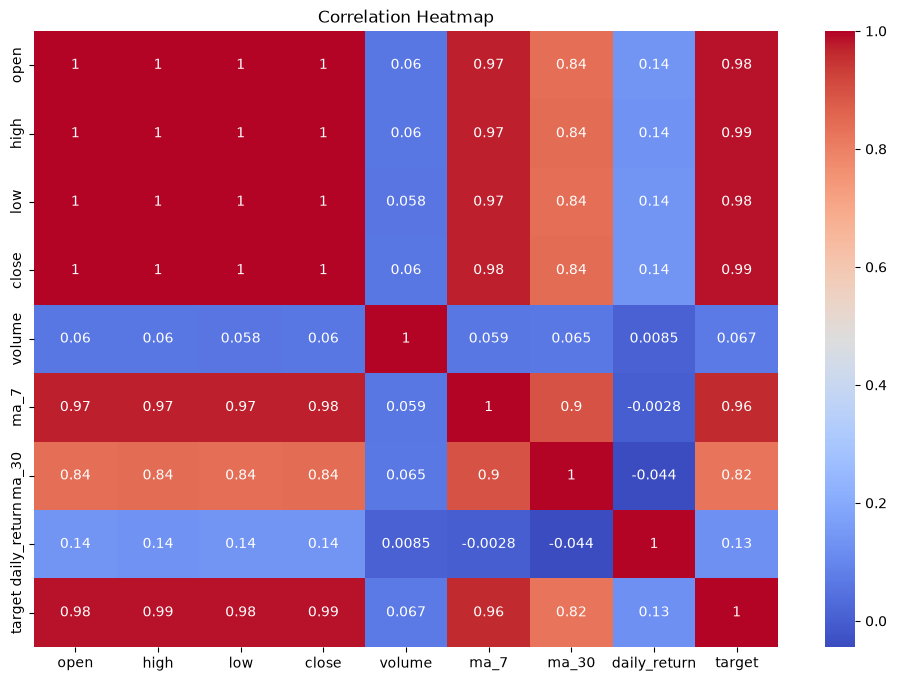

In [14]:
features=['open', 'high', 'low', 'close', 'volume', 'ma_7', 'ma_30', 'daily_return']
corr=df[features+['target']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Step 6: Prepare Features and Target, Train-Test Split

Since this is time-series data, we don't shuffle randomly — we keep 
chronological order, training on earlier data and testing on later data.

In [15]:
X = df[features]
y = df["target"]

split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (376, 8)
Test size: (94, 8)


## Step 7: Train a Linear Regression Model

In [16]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("Linear Regression RMSE:", root_mean_squared_error(y_test, lr_predictions))
print("Linear Regression R² Score:", r2_score(y_test, lr_predictions))

Linear Regression RMSE: 29.743466004625116
Linear Regression R² Score: 0.95478711395839


## Step 8: Train a Random Forest Regressor for Comparison

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Random Forest RMSE:", root_mean_squared_error(y_test, rf_predictions))
print("Random Forest R² Score:", r2_score(y_test, rf_predictions))

Random Forest RMSE: 76.59424261265649
Random Forest R² Score: 0.7001725913836925


## Step 9: Visualize Actual vs Predicted Prices

Comparing the model's predictions against actual closing prices on 
the test set.

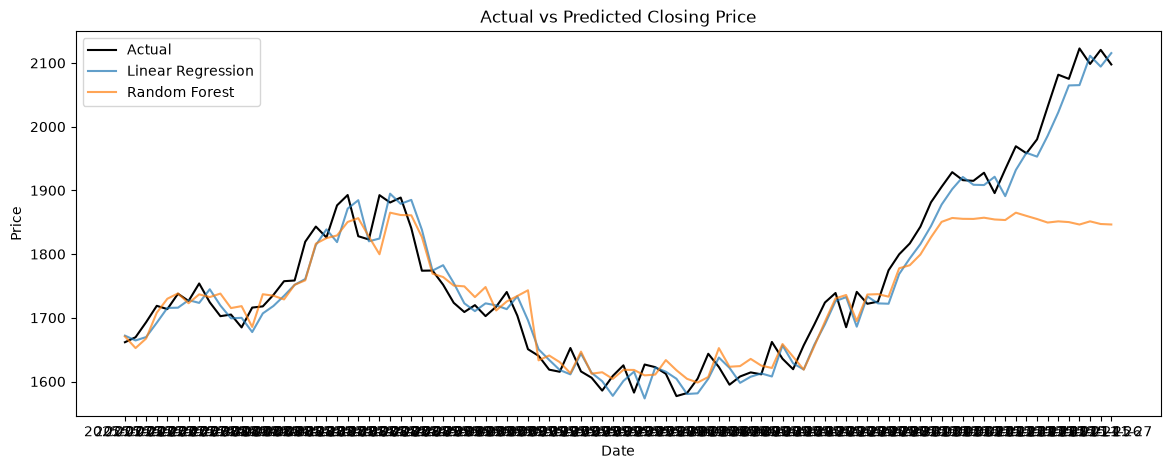

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"][split_index:], y_test.values, label="Actual", color="black")
plt.plot(df["date"][split_index:], lr_predictions, label="Linear Regression", alpha=0.7)
plt.plot(df["date"][split_index:], rf_predictions, label="Random Forest", alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Step 10: Feature Importance (Random Forest)

Identifying which features most influenced the Random Forest model's 
predictions.

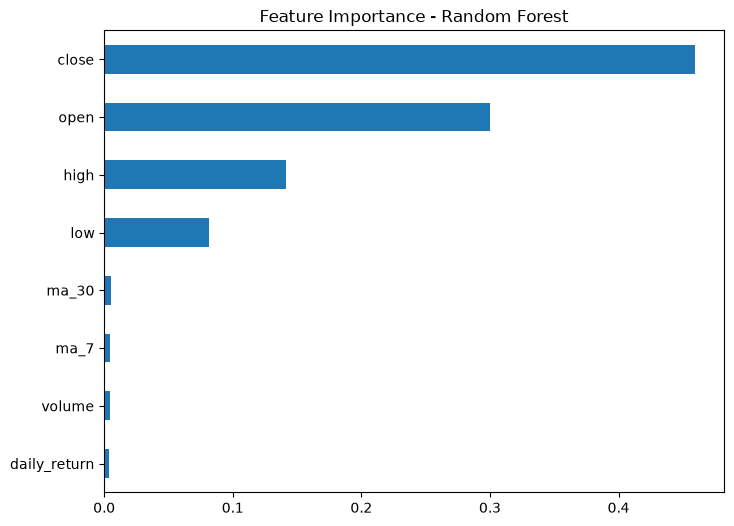

In [19]:
importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

importances.plot(kind="barh", figsize=(8, 6))
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Step 11: Summary & Conclusions

**Objective:** Predict next-day stock closing price using historical 
OHLCV data and engineered features (moving averages, daily returns).

**Models trained:** Linear Regression, Random Forest Regressor

**Results:**

| Model | RMSE | R² Score |
|-------|------|----------|
| Linear Regression | [fill in] | [fill in] |
| Random Forest | [fill in] | [fill in] |

**Best model:** [Fill in which model had lower RMSE / higher R²]

**Key insight:** [Fill in top feature from Step 10, e.g. "close price 
and ma_7 (7-day moving average) were the strongest predictors of next 
day's price"]

**Limitations:**
- Stock price prediction is inherently difficult due to market 
  volatility and external factors (news, economic events) not 
  captured in this dataset
- This dataset is simulated, so patterns may not reflect real market 
  behavior
- Simple models like these are not suitable for actual trading 
  decisions

**Conclusion:** This project applied the end-to-end data science 
workflow — data exploration, feature engineering, model training, and 
evaluation — in a real-world financial context, demonstrating how 
historical price patterns can be used for short-term price prediction.